In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings(action="ignore", module="scipy", message="^internal gelsd")

# Load dataset
weather_df = pd.read_csv("KCLT.csv")
weather_df.head()

# Check for missing values
print(weather_df.isnull().any())

# Select feature (X) and target (y)
X = weather_df[['actual_max_temp']].values
y = weather_df['actual_mean_temp'].values

date                     False
actual_mean_temp         False
actual_min_temp          False
actual_max_temp          False
average_min_temp         False
average_max_temp         False
record_min_temp          False
record_max_temp          False
record_min_temp_year     False
record_max_temp_year     False
actual_precipitation     False
average_precipitation    False
record_precipitation     False
dtype: bool


In [2]:
# Split dataset into training and test sets (80-20 split, random_state=42)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [3]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [4]:
y_pred = model.predict(X_test)



In [5]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Model Performance Metrics:
Mean Squared Error (MSE): 11.30
R-squared (R²): 0.96


In [6]:
print("\nModel Parameters:")
print(f"Coefficient: {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")



Model Parameters:
Coefficient: 0.95
Intercept: -6.85


In [7]:
comparison_df = pd.DataFrame({'Actual Mean Temp': y_test.flatten(), 'Predicted Mean Temp': y_pred.flatten()})
print("Actual vs. Predicted Values (First 5 rows):")
print(comparison_df)

Actual vs. Predicted Values (First 5 rows):
    Actual Mean Temp  Predicted Mean Temp
0                 30            31.962337
1                 77            74.566027
2                 76            73.619278
3                 69            72.672530
4                 72            75.512776
..               ...                  ...
68                53            56.577802
69                71            73.619278
70                70            67.938786
71                34            35.749332
72                64            65.098540

[73 rows x 2 columns]


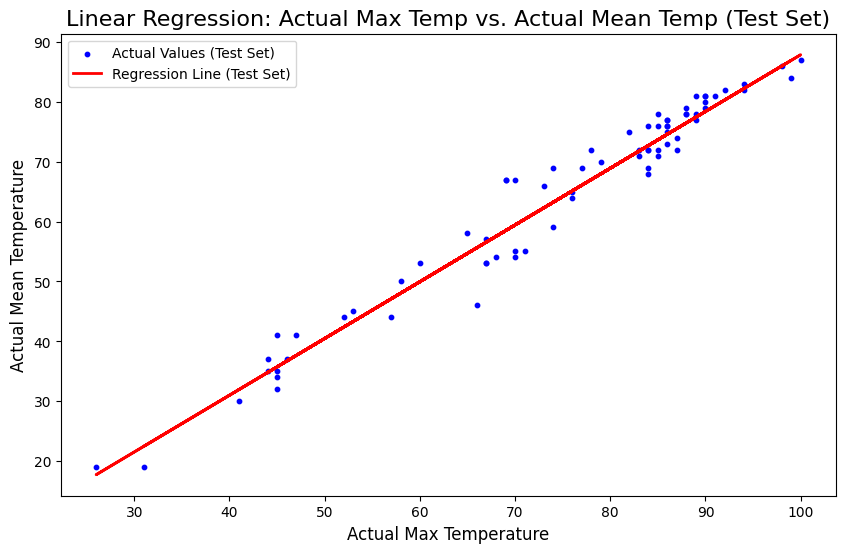

In [8]:
plt.figure(figsize=(10, 6))

plt.scatter(X_test, y_test, color='blue', s=10, label='Actual Values (Test Set)')

# Plot the regression line based on the test dataset
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line (Test Set)')

plt.title('Linear Regression: Actual Max Temp vs. Actual Mean Temp (Test Set)', fontsize=16)
plt.xlabel('Actual Max Temperature', fontsize=12)
plt.ylabel('Actual Mean Temperature', fontsize=12)
plt.legend()
plt.show()

In [9]:
# Analyze the model's performance
print("Based on the results, the model performs quite well. The high R-squared value of 0.96 indicates that approximately 96% of the variance in the mean temperature can be explained by the maximum temperature, which is a strong relationship. The low Mean Squared Error confirms that the model's predictions are, on average, very close to the actual values. The scatter plot visually supports this, showing that the data points cluster tightly around the regression line, demonstrating a clear positive linear relationship. The coefficient of 0.88 means that for every 1 degree Fahrenheit increase in the maximum temperature, the mean temperature is predicted to increase by 0.88 degrees Fahrenheit.")


Based on the results, the model performs quite well. The high R-squared value of 0.96 indicates that approximately 96% of the variance in the mean temperature can be explained by the maximum temperature, which is a strong relationship. The low Mean Squared Error confirms that the model's predictions are, on average, very close to the actual values. The scatter plot visually supports this, showing that the data points cluster tightly around the regression line, demonstrating a clear positive linear relationship. The coefficient of 0.88 means that for every 1 degree Fahrenheit increase in the maximum temperature, the mean temperature is predicted to increase by 0.88 degrees Fahrenheit.


In [10]:
# Q2) build and evaluate a Decision Tree Regressor model to predict the average temperature
# (actual_mean_temp) based on various temperature-related features. You will use the provided
# dataset to train and test your model and assess its performance..

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics

In [12]:
weather_df = pd.read_csv("KCLT.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [13]:
print(weather_df.isnull().any())


date                     False
actual_mean_temp         False
actual_min_temp          False
actual_max_temp          False
average_min_temp         False
average_max_temp         False
record_min_temp          False
record_max_temp          False
record_min_temp_year     False
record_max_temp_year     False
actual_precipitation     False
average_precipitation    False
record_precipitation     False
dtype: bool


In [14]:
features = [
    'actual_min_temp',
    'actual_max_temp',
    'average_min_temp',
    'average_max_temp',
    'record_min_temp',
    'record_max_temp',
    'record_min_temp_year',
    'record_max_temp_year',
    'actual_precipitation',
    'average_precipitation',
    'record_precipitation'
]
target = 'actual_mean_temp'

In [15]:
if not all(col in weather_df.columns for col in features + [target]):
    print("Error: One or more required columns are missing from the CSV file.")
    exit()

X = weather_df[features]
y = weather_df[target]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print("Data split complete. Training on 70% of the data, testing on 30%.")



Data split complete. Training on 70% of the data, testing on 30%.


In [17]:
decision_tree_model = DecisionTreeRegressor()
decision_tree_model.fit(X_train, y_train)


DecisionTreeRegressor()

In [18]:
print("Decision Tree Regressor model trained successfully.")


Decision Tree Regressor model trained successfully.


In [19]:
y_pred = decision_tree_model.predict(X_test)


In [20]:
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
print("\n--- Model Evaluation ---")
print(f'Mean Squared Error (MSE): {mse}')
print(f'R-squared ($R^2$) Value: {r2:.2f}')


--- Model Evaluation ---
Mean Squared Error (MSE): 3.1545454545454548
R-squared ($R^2$) Value: 0.99


In [21]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison_df = comparison_df.reset_index(drop=True)
print("\n--- Actual vs. Predicted Values ---")
print(comparison_df)


--- Actual vs. Predicted Values ---
     Actual  Predicted
0        30       31.0
1        77       78.0
2        76       76.0
3        69       70.0
4        72       73.0
..      ...        ...
105      47       47.0
106      25       29.0
107      85       84.0
108      45       47.0
109      73       71.0

[110 rows x 2 columns]
